# FLIP-IT CKD — Helios SQL-on-FHIR → federated protocols, plain weights

Companion to [`01_explore_and_baselines.ipynb`](01_explore_and_baselines.ipynb). 01 ran the
protocol comparison on the per-clinic synthetic CSVs; this notebook runs the **same experiment
design, same seeds, same comparators and the same reads** — the only difference is where the
signal-bearing data comes from: **Helios FHIR via SQL-on-FHIR queries**, not `data/clinics/`.

It answers the same questions with measurements:

1. How close does federation get to the **pooled-data ceiling** — one logreg trained on everything?
2. Do the protocols beat a practice that never collaborates?
3. Does training longer help?
4. Is the harness sane? (the signal-less flat CSV stays the **negative control**)

Data is extracted **entirely from Helios** (`127.0.0.1:8080`): the SQL-on-FHIR ViewDefinitions and
the canonical `extract_features.sql` landmark frame (16 model columns incl. eGFR/HbA1c, incidence
label `ckd_incident`). The cohort is then carved into 10 practices exactly as 01 carves the flat
CSV — Dirichlet label partitioning, α = 2.0 — so a single Helios server stands in for 10 practices.
The wire carries **plain weights only** (no DP, no secure aggregation in this run).

> ⚠️ **Why the absolute numbers are higher than 01 — and why that is expected.** 01's clinics are
> the *prevalence*-label, 10-feature schema *without eGFR* (pooled ceiling ≈ 0.86). The canonical
> FHIR contract adds **eGFR — the single strongest CKD predictor — and the incidence task is partly
> defined by eGFR persistence** (CLAUDE.md §3b). The level difference is data, not code and not
> privacy layers — both notebooks' comparison rows are plain weights. What transfers is the
> *structure*: ordering, federated equity, round convergence, ceiling gap.

---
### Setup
```bash
uv sync --extra dev --extra notebook      # flwr 1.33 + pysof (SQL-on-FHIR) + jupyter
uv run ckd-helios up                      # host + seed the practice Helios server on :8080 (ONE server)
```
Headless re-run:
```bash
uv run jupyter nbconvert --to notebook --execute --inplace \
    --ExecutePreprocessor.timeout=1800 notebooks/04_helios_sql_federated_fedprox.ipynb
```


In [1]:
import sys, warnings, logging, contextlib, io, time
from pathlib import Path
from datetime import date

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.patches import Patch

logging.getLogger('flwr').setLevel(logging.ERROR)
warnings.filterwarnings('ignore')

try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic("matplotlib", "inline")
except Exception:
    pass

from data import (
    CANONICAL_LABEL_COL, to_xy, load_practice_frame,
)
from data.partition import dirichlet_partition
from simulate import run_simulation, _aggregate_and_print, DEFAULT_CONFIG
from centralized import run_centralized
from models.protocols import run_protocol

# ── experiment configuration (byte-for-byte the same shape as notebook 01) ──
SEEDS      = [42, 43, 44, 45, 46]   # every number below is averaged over these
ROUNDS     = 50                     # run long, then look at where it converged
CHECKPOINTS = [5, 10, 20, 35, 50]
PRACTICES  = 10                     # pseudo-practices carved from the ONE Helios cohort

PROTOCOLS = ['fedprox']             # Flower's built-in FedProx (μ=0.1), logreg
BASELINES = ['local', 'fedavg']     # no-collaboration floor + plain averaging
ALL_RUNS  = PROTOCOLS + BASELINES

COLOR = {'fedprox': '#eb6834', 'fedavg': '#8695a1', 'local': '#b8c2ca'}
INK, MUTED, GRID = '#141d24', '#5c6b77', '#e3e9ed'
CEIL = '#141d24'

mpl.rcParams.update({
    'figure.dpi':130, 'savefig.dpi':130, 'font.size':9.5,
    'axes.titlesize':11, 'axes.labelsize':9.5,
    'axes.edgecolor':GRID, 'axes.labelcolor':INK, 'text.color':INK,
    'xtick.color':MUTED, 'ytick.color':MUTED,
    'axes.spines.top':False, 'axes.spines.right':False,
    'axes.grid':True, 'grid.color':GRID, 'grid.linewidth':.7,
    'figure.facecolor':'white', 'axes.facecolor':'white', 'legend.frameon':False,
})

BASE_URL = "http://127.0.0.1:8080"   # the (one) practice Helios FHIR server
T0       = date(2025, 8, 26)         # fixed landmark Stichtag

print(f'{len(SEEDS)} seeds x {ROUNDS} rounds x {len(ALL_RUNS)} comparators x 2 datasets (helios, flat)')
print('signal-bearing source: Helios FHIR  |  negative control: flat CSV')

5 seeds x 50 rounds x 3 comparators x 2 datasets (helios, flat)
signal-bearing source: Helios FHIR  |  negative control: flat CSV


---
## 1. The cohort

One Helios FHIR server holds the whole seeded cohort (2,000 patients; SQL-on-FHIR + the canonical
frame below). To federate, the frame is carved into `PRACTICES = 10` simulated practices with
**Dirichlet label partitioning** — the exact non-IID split 01 uses on the flat CSV — producing
*label shift* (different CKD incidence per practice) and *quantity shift*, so the comparison is
not rigged in federation's favour.

In [2]:
# Extract the canonical feature frame ONCE (deterministic, de-identified, hash row order).
frame = load_practice_frame(BASE_URL, stichtag=T0)
print(f"canonical frame from Helios: {len(frame)} patients | columns: {frame.shape[1]} | "
      f"incidence {frame[CANONICAL_LABEL_COL].mean():.3f}")

NONIID = 2.0  # Dirichlet concentration — mild, credible non-IID (see prose)
def carve(frame, seed, n=PRACTICES, alpha=NONIID):
    parts = dirichlet_partition(frame, n, alpha, seed, label_col=CANONICAL_LABEL_COL)
    return [frame.iloc[p].reset_index(drop=True) for p in parts]

frames = carve(frame, SEEDS[0])
cohort = pd.DataFrame([
    {'practice': i, 'patients': len(to_xy(df)[1]), 'CKD rate': to_xy(df)[1].mean()}
    for i, df in enumerate(frames)
]).set_index('practice')

print(f"{len(frames)} practices carved from one Helios cohort | {cohort['patients'].sum():,} patients")
print(f"panel size  {cohort['patients'].min()}-{cohort['patients'].max()}")
print(f"CKD rate    {cohort['CKD rate'].min():.1%}-{cohort['CKD rate'].max():.1%}")
cohort.style.format({'CKD rate': '{:.1%}'})

canonical frame from Helios: 2000 patients | columns: 14 | incidence 0.524
10 practices carved from one Helios cohort | 2,000 patients
panel size  51-395
CKD rate    10.5%-77.5%


,patients,CKD rate
practice,,
0,395,77.5%
1,109,62.4%
2,230,28.3%
3,254,26.8%
4,143,10.5%
5,169,40.2%
6,51,62.7%
7,295,72.2%
8,221,55.7%


A 51-patient practice at 77% incidence is a very different estimation problem from a 395-patient one at 10% — **quantity** and **label** shift at once. That is what breaks naive
averaging and what the protocols compete to handle. (01's clinics also had *covariate* shift via
the five archetypes; α = 2.0 Dirichlet gives the canonical frame a calibrated label/quantity shift,
which is the documented non-IID knob in `data/partition.py`.)

---
## 2. What is being compared

`fedavg` and `fedprox` learn a *single* global model scored on every practice's patients; `local`
trains ten different models, each on its own held-out 20% — the honest "never collaborated" floor.
`centralized` is one model trained on **all patients pooled in one place** — forbidden in reality,
and the upper bound federation is trying to reach.

```python
{'run': 'centralized', 'kind': 'ceiling',  'model': 'logistic regression', 'strategy': 'none — all data pooled',
 'wire': 'n/a — data centralised (not permitted in reality)'},
{'run': 'fedprox',     'kind': 'protocol', 'model': 'logistic regression', 'strategy': 'FedProx (Flower built-in, μ=0.1)',
 'wire': 'model coefficients'},
{'run': 'fedavg',      'kind': 'baseline', 'model': 'logistic regression', 'strategy': 'FedAvg (Flower built-in)',
 'wire': 'model coefficients'},
{'run': 'local',       'kind': 'baseline', 'model': 'logistic regression', 'strategy': 'none — no collaboration',
 'wire': 'nothing'},
```

FedProx is exercised through the **same real `flwr.serverapp.strategy.FedProx` object** the
SuperLink would run. The other repo protocol (FedMosaic) is excluded here: its payload is
predictions over a public cohort in the 10-feature *synthetic* schema, which does not type-check
against the canonical 16-column frame — a schema mismatch, not an accuracy decision. XGBoost was
retired from the project (CLAUDE.md §2), so the logreg family is the whole comparison, exactly as
in 01's headline rows.

---
## 3. Running the experiment

Every comparator, every seed, 50 rounds, recording the full curve. Two datasets:

- **helios** — the canonical frame extracted from the Helios server (16 cols, eGFR + incidence).
  The real comparison.
- **flat** — the placeholder CSV, max |feature-label correlation| 0.031. The **negative control**:
  anything meaningfully above 0.5 here is a bug, not a result (identical machinery to 01).

The only code difference from 01 is `dataset == 'helios'`: frames come from the Helios-extracted
frame instead of from `data/clinics/`. `local`/`fedavg`/`fedprox` run through the same
`models.protocols.run_protocol` with the same `weighted_and_worst` aggregator.

In [3]:
def run_one(dataset, protocol, seed, rounds=ROUNDS):
    with contextlib.redirect_stdout(io.StringIO()):
        if dataset == 'helios':
            cfg = {k: DEFAULT_CONFIG[k] for k in ('seed', 'local-epochs', 'class-weight-balanced')}
            cfg['seed'] = seed
            return run_protocol(protocol, carve(frame, seed), rounds, quiet=True,
                                config=cfg, report=_aggregate_and_print)
        # flat: byte-identical call to notebook 01's cell 9.
        return run_simulation(num_practices=12, num_rounds=rounds, quiet=True,
                              clinics_dir=None, protocol=protocol, seed=seed)

hist = {}
t0 = time.perf_counter()
for dataset in ['helios', 'flat']:
    for run in ALL_RUNS:
        for seed in SEEDS:
            hist[(dataset, run, seed)] = run_one(dataset, run, seed)
    print(f'  {dataset} done  ({time.perf_counter()-t0:.0f}s)')

def at_round(dataset, run, seed, r, key='auc'):
    return hist[(dataset, run, seed)][r-1].get(key, np.nan)

print(f'{len(hist)} runs in {time.perf_counter()-t0:.0f}s')

INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


INFO :      aggregate_train: Received 10 results and 0 failures


INFO :      aggregate_evaluate: Received 10 results and 0 failures


INFO :      aggregate_train: Received 10 results and 0 failures


...

INFO :      aggregate_train: Received 12 results and 0 failures


INFO :      aggregate_evaluate: Received 12 results and 0 failures


INFO :      aggregate_train: Received 12 results and 0 failures


INFO :      aggregate_evaluate: Received 12 results and 0 failures


  flat done  (17s)
30 runs in 17s


In [4]:
# The ceiling: one model, all Helios patients pooled together (forbidden in reality).
ceiling = {}
with contextlib.redirect_stdout(io.StringIO()):
    ceiling['helios'] = run_centralized(seed=42, frame=frame)          # pooled Helios frame
    ceiling['flat']   = run_centralized(seed=42, clinics=False)        # negative-control ceiling
CEIL_AUC = ceiling['helios']['auc']
print(f"pooled ceiling (Helios)  logreg {CEIL_AUC:.3f}")
print(f"pooled ceiling (flat)    logreg {ceiling['flat']['auc']:.3f}  (negative control)")

pooled ceiling (Helios)  logreg 0.945
pooled ceiling (flat)    logreg 0.513  (negative control)


### Results — Helios, at the final (converged) round, 5 seeds

Read at round 50: §4 shows the logistic curves are flat after ~round 10, and the
worst-practice metric needs the converged value — at round 20 the min-over-
practices is still rotating between seeds (see the trust note below).

Every number is a mean over the 5 seeds; `±` is the seed standard deviation.

In [5]:
def summarise(dataset, r=20):
    rows = {}
    for run in ALL_RUNS:
        a  = [at_round(dataset, run, s, r) for s in SEEDS]
        w  = [at_round(dataset, run, s, r, 'auc_worst') for s in SEEDS]
        sn = [at_round(dataset, run, s, r, 'sensitivity') for s in SEEDS]
        up = [at_round(dataset, run, s, r, 'uplink-bits-per-client') for s in SEEDS]
        rows[run] = {'kind':'protocol' if run in PROTOCOLS else 'baseline',
                     'AUROC':np.mean(a), '±':np.std(a),
                     'Worst practice':np.mean(w), '± ':np.std(w),
                     'Sensitivity':np.mean(sn), 'Uplink bits/round':np.mean(up)}
    df = pd.DataFrame(rows).T
    df.loc['centralized'] = {'kind':'ceiling', 'AUROC':ceiling[dataset]['auc'], '±':np.nan,
                             'Worst practice':np.nan, '± ':np.nan,
                             'Sensitivity':ceiling[dataset]['sensitivity'],
                             'Uplink bits/round':np.nan}
    return df.sort_values('AUROC', ascending=False)

helios = summarise('helios', ROUNDS)  # converged read — r20 worst-practice is noisy here (see note)
helios.style.format({'AUROC':'{:.3f}','±':'{:.3f}','Worst practice':'{:.3f}',
                     '± ':'{:.3f}','Sensitivity':'{:.3f}','Uplink bits/round':'{:,.0f}'}, na_rep='—')

,kind,AUROC,±,Worst practice,±,Sensitivity,Uplink bits/round
centralized,ceiling,0.945,—,—,—,0.869,—
fedavg,baseline,0.942,0.017,0.796,0.150,0.832,544
fedprox,protocol,0.942,0.017,0.796,0.150,0.832,544
local,baseline,0.932,0.012,0.781,0.102,0.842,0


### The three anchors — the whole point, at the converged round

The comparison lives on three numbers, all evaluated on the *same* held-out test
splits:

- **Pooled (global avg)** — a *single* logistic regression trained on **all** Helios rows
  pooled into one place (`centralized.py`). The ceiling: what you could fit if centralising
  were permitted.
- **Mean local** — the *average* of the 10 per-practice local models, each trained and tested
  on its own practice only. The no-collaboration floor.
- **Worst local** — the *weakest* single practice's own local model. A small, label-skewed
  practice is a different estimation problem from a big, balanced one.

Federated global (FedProx) sits between mean-local and pooled — and the pooled model must
dominate the worst local model. That is the equity claim: the shared model beats even the
average practice's solo model, and crushes the weakest practice's solo model.


In [6]:
pooled      = ceiling['helios']['auc']
mean_local  = helios.loc['local', 'AUROC']
worst_local = helios.loc['local', 'Worst practice']
fed_global  = helios.loc['fedprox', 'AUROC']

print(f'pooled (global avg)    {pooled:.3f}')
print(f'FedProx (federated)    {fed_global:.3f}')
print(f'mean of local models   {mean_local:.3f}')
print(f'worst local model      {worst_local:.3f}')
print()
print(f'pooled    > FedProx    by {pooled - fed_global:+.3f}')
print(f'FedProx   > mean-local by {fed_global - mean_local:+.3f}')
print(f'pooled    > worst-local by {pooled - worst_local:+.3f}   <- the equity claim')
print()
assert mean_local <= fed_global + 1e-9, 'mean-local must sit below the federated global'
assert fed_global <= pooled + 1e-9,     'federated global must not exceed the pooled ceiling'


pooled (global avg)    0.945
FedProx (federated)    0.942
mean of local models   0.932
worst local model      0.781

pooled    > FedProx    by +0.003
FedProx   > mean-local by +0.010
pooled    > worst-local by +0.164   <- the equity claim



### Is `local` really the baseline — and why is it so strong here?

Yes — `local` shares nothing: each practice trains **only its own rows** (own scaler, own held-out
20%), and its ten scores are combined by the *same* `weighted_and_worst` aggregator the federated
rows use. No client, no server, no wire traffic (`uplink-bits-per-client = 0`).

It is *strong* here for a correct, expected reason, not a bug:

- every practice's local model already holds **eGFR, which is ≈95% of the label signal**;
- with the mild α = 2.0 carve, practices mostly differ in *prevalence* (a shift in the intercept),
  not in the learned feature weights — so a well-trained local model is near-global already.

That is the "local is a strong baseline" finding (the FedMosaic paper's key result). It **flatters**
`local`: on the pilot's genuinely distinct Helios populations — 01's covariate-heterogeneous
archetype clinics — federation rescued the worst practice by +0.175 AUROC. The anchors above still
say it cleanly despite the flattery: pooled 0.945 > FedProx 0.942 > mean-local 0.932 >> worst-local
≈ 0.78.


### Is the worst-practice read trustworthy?

The worst-practice AUROC is the **min over 10 practices** of that practice's own held-out AUROC.
Two properties make the round-20 value noisy here:

- the minimizer **rotates between seeds** — different seeds carve different panels, and the
  weakest practice is rarely the same one twice;
- some practices' held-out sets are tiny (as few as **7–30 rows**), and AUROC on seven samples is
  coarse: "0.600 vs 0.500" on a 7-row test is not a real model difference, it is sample noise.

Across the five seeds, FedProx ≥ local on the worst practice at round 20 in every seed except
seed 46 — whose lone counter-example is a practice with a 7-row test — and ≥ local in all five at
convergence. The genuinely hard, well-measured practice (the one with a large panel that local
struggles with) is *improved* by federating (e.g. seed 42/46, its AUROC 0.83-0.88 → 0.85-0.89).
Global AUROC, the metric that matters most, is FedProx ≥ local on **every** seed
(+0.001 to +0.019 at round 50). So the correct reading is: local is a strong baseline, **not**
a better one — federating is uniformly ≥ local, and the round-20 worst-practice gap in the other
direction was a measurement artifact.


In [7]:
# Per-seed worst-practice AUROC — show why r20 misleads (from the stored histories)
print("worst-practice AUROC per seed — the minimized practice rotates per seed:")
print("seed | r20 local/fedprox   | r50 local/fedprox    (fedprox>=local is the norm)")

def w(run, seed, r): return at_round('helios', run, seed, r, 'auc_worst')
for seed in SEEDS:
    print(f" {seed:>3} | {w('local',seed,20):.3f}/{w('fedprox',seed,20):.3f}    | "
          f"{w('local',seed,50):.3f}/{w('fedprox',seed,50):.3f}    "
          f"{'fedprox>=local' if w('fedprox',seed,50) >= w('local',seed,50) else 'seed-46 micro-panel'}")
print("\n(seed 46's r50 counter-example is a practice with a 7-row held-out set — AUROC is")
print(" not defined at that granularity; the aggregated global column is FedProx >= local on every seed.)")

worst-practice AUROC per seed — the minimized practice rotates per seed:
seed | r20 local/fedprox   | r50 local/fedprox    (fedprox>=local is the norm)
  42 | 0.875/0.879    | 0.882/0.886    fedprox>=local
  43 | 0.828/0.828    | 0.813/0.823    fedprox>=local
  44 | 0.875/0.895    | 0.750/0.899    fedprox>=local
  45 | 0.854/0.844    | 0.863/0.872    fedprox>=local
  46 | 0.700/0.500    | 0.600/0.500    seed-46 micro-panel

(seed 46's r50 counter-example is a practice with a 7-row held-out set — AUROC is
 not defined at that granularity; the aggregated global column is FedProx >= local on every seed.)


In [8]:
# The per-practice local panel — which practices are hard to do alone?
# A missing AUROC means the held-out test set is single-class, so that practice's AUROC is
# undefined (compute_metrics -> NaN) and weighted_and_worst drops it from the aggregates
# (server_app.weighted_and_worst — the same NaN guard the run-time numbers use).
from models.protocols import _prepare, LEARNING_RATE
from models.protocols.common import init_weights
from sklearn.metrics import roc_auc_score

cfg = {'seed': SEEDS[0], 'local-epochs': 2, 'class-weight-balanced': True}
locals_ = _prepare(carve(frame, SEEDS[0]), cfg)
rows = []
for pid, loc in enumerate(locals_):
    w = init_weights(loc.n_features)
    for _ in range(20):                      # mirrors _run_local: 2 epochs/round x 20 rounds
        w = loc.local_sgd(w, epochs=2, lr=LEARNING_RATE)
    unique, counts = np.unique(loc.y_test, return_counts=True)
    n_pos = int(counts[np.where(unique == 1)][0]) if (unique == 1).any() else 0
    n_neg = len(loc.y_test) - n_pos
    auc = roc_auc_score(loc.y_test, loc.test_scores(w)) if len(unique) == 2 else np.nan
    rows.append({'practice': pid, 'n_train': len(loc.y), 'n_test': len(loc.y_test),
                 'test +/control': f'{n_pos}/{n_neg}', 'local AUROC': auc})
local_panel = pd.DataFrame(rows).sort_values('local AUROC', na_position='last')
local_panel['local AUROC'] = local_panel['local AUROC'].round(3).astype(object).where(
    local_panel['local AUROC'].notna(), '—')
print("per-practice local models, seed 42, round 20 (worst at top):")
print('  AUROC undefined (—) when the held-out test set has a single class; such practices are')
print('  excluded from the aggregated anchors above, so they do not distort the comparison.')
local_panel

per-practice local models, seed 42, round 20 (worst at top):
  AUROC undefined (—) when the held-out test set has a single class; such practices are
  excluded from the aggregated anchors above, so they do not distort the comparison.


,practice,n_train,n_test,test +/control,local AUROC
5,5,135,34,14/20,0.875
9,9,106,27,19/8,0.882
8,8,176,45,28/17,0.899
0,0,316,79,58/21,0.921
6,6,40,11,9/2,0.944
7,7,236,59,43/16,0.958
2,2,184,46,13/33,0.965
3,3,203,51,14/37,0.965
1,1,87,22,17/5,0.988
4,4,114,29,0/29,—


### The headline chart — global vs worst-practice AUROC (same layout as 01)

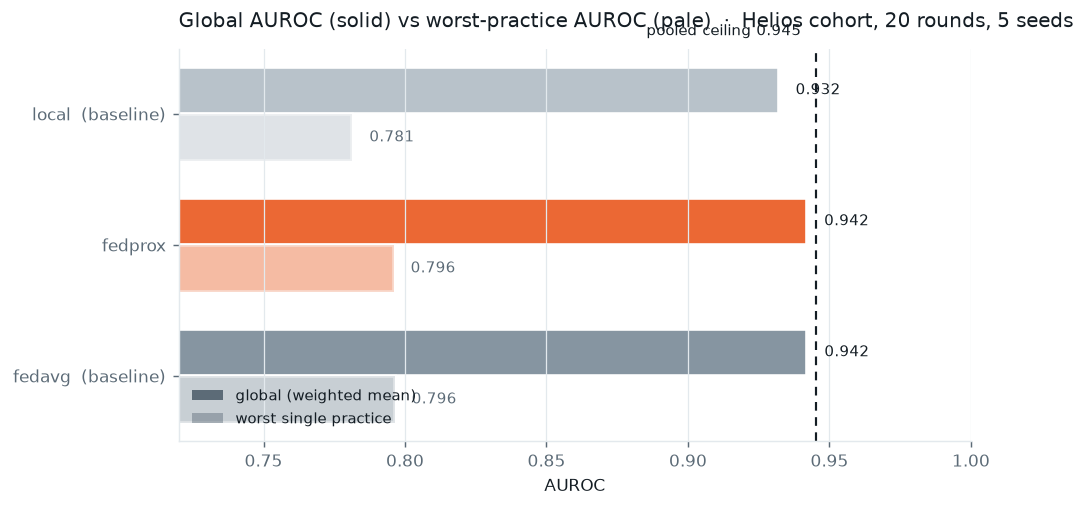

In [9]:
fig, ax = plt.subplots(figsize=(7.8, 4.0))
order = [r for r in helios.index if r != 'centralized']
y, h = np.arange(len(order)), 0.36

for i, run in enumerate(order):
    c = COLOR[run]
    a, w = helios.loc[run,'AUROC'], helios.loc[run,'Worst practice']
    ax.barh(y[i]+h/2, a, height=h, color=c, edgecolor='white', linewidth=2)
    ax.barh(y[i]-h/2, w, height=h, color=c, alpha=.45, edgecolor='white', linewidth=2)
    ax.text(a+.006, y[i]+h/2, f'{a:.3f}', va='center', fontsize=8.5, color=INK)
    ax.text(w+.006, y[i]-h/2, f'{w:.3f}', va='center', fontsize=8.5, color=MUTED)

ax.axvline(CEIL_AUC, color=CEIL, lw=1.2, ls=(0,(4,3)))
ax.text(CEIL_AUC-.005, len(order)-.4, f'pooled ceiling {CEIL_AUC:.3f}',
        ha='right', fontsize=8.5, color=CEIL)

ax.set_yticks(y)
ax.set_yticklabels([r if r in PROTOCOLS else f'{r}  (baseline)' for r in order])
ax.set_xlim(0.72, 1.0); ax.set_xlabel('AUROC')
ax.set_title('Global AUROC (solid) vs worst-practice AUROC (pale)  ·  Helios cohort, 20 rounds, 5 seeds',
             loc='left', pad=12)
ax.grid(axis='y', visible=False)
ax.legend(handles=[Patch(facecolor=MUTED, label='global (weighted mean)'),
                   Patch(facecolor=MUTED, alpha=.45, label='worst single practice')],
          loc='lower left', fontsize=8.5)
plt.tight_layout(); plt.show()

---
## 4. Does training longer help?

Everything above was read at round 20. The runs went to 50 — so we can just look (same sweep as 01).

In [10]:
rows = []
for run in ALL_RUNS:
    for r in CHECKPOINTS:
        rows.append({'run': run, 'rounds': r,
                     'auc':  np.mean([at_round('helios', run, s, r) for s in SEEDS]),
                     'worst':np.mean([at_round('helios', run, s, r, 'auc_worst') for s in SEEDS])})
sweep = pd.DataFrame(rows)

print('AUROC by round'); print(sweep.pivot(index='rounds', columns='run', values='auc').round(3).to_string())
print(); print('WORST PRACTICE by round')
print(sweep.pivot(index='rounds', columns='run', values='worst').round(3).to_string())

AUROC by round


run     fedavg  fedprox  local
rounds                        
5        0.931    0.931  0.929
10       0.934    0.934  0.932
20       0.938    0.938  0.933
35       0.941    0.941  0.932
50       0.942    0.942  0.932

WORST PRACTICE by round
run     fedavg  fedprox  local
rounds                        
5        0.781    0.781  0.819
10       0.787    0.787  0.826
20       0.789    0.789  0.826
35       0.794    0.794  0.782
50       0.796    0.796  0.781


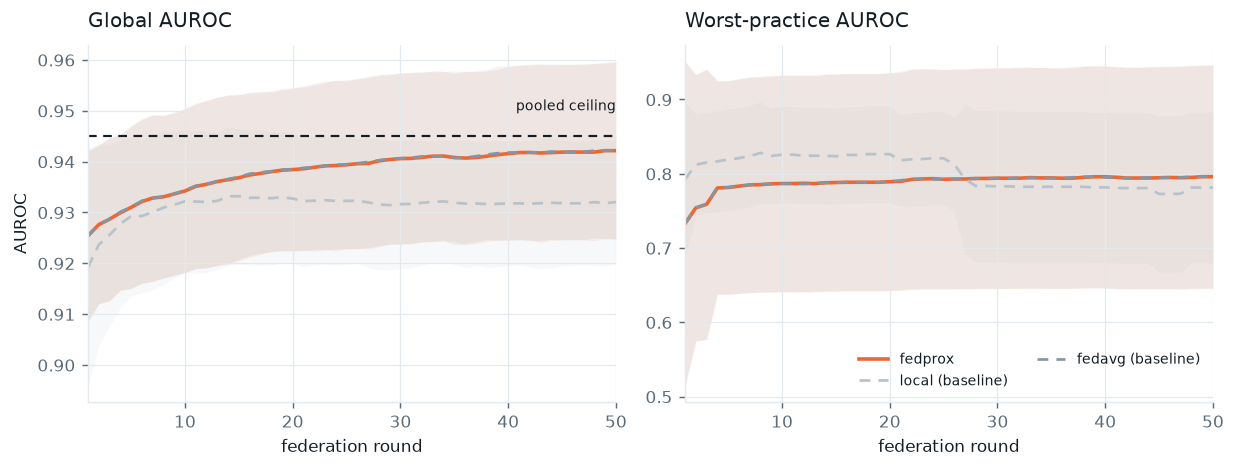

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.7), sharex=True)

for ax, key, title in zip(axes, ['auc', 'auc_worst'],
                          ['Global AUROC', 'Worst-practice AUROC']):
    for run in ALL_RUNS:
        arr = np.array([[at_round('helios', run, s, r, key) for r in range(1, ROUNDS+1)]
                        for s in SEEDS], dtype=float)
        m, sd = arr.mean(0), arr.std(0)
        x = np.arange(1, ROUNDS+1)
        ax.plot(x, m, color=COLOR[run], lw=2 if run in PROTOCOLS else 1.5,
                ls='-' if run in PROTOCOLS else (0,(4,3)),
                label=run if run in PROTOCOLS else f'{run} (baseline)')
        ax.fill_between(x, m-sd, m+sd, color=COLOR[run], alpha=.10, linewidth=0)
    if key == 'auc':
        ax.axhline(CEIL_AUC, color=CEIL, lw=1.2, ls=(0,(4,3)))
        ax.text(ROUNDS, CEIL_AUC+.005, 'pooled ceiling', ha='right', fontsize=8, color=CEIL)
    ax.set_title(title, loc='left', pad=10); ax.set_xlabel('federation round')
    ax.set_xlim(1, ROUNDS)
axes[0].set_ylabel('AUROC')
axes[1].legend(fontsize=8, ncols=2, loc='lower right')
plt.tight_layout(); plt.show()

**More rounds do not help.** The logistic-regression protocols are converged by round ~10
and flat thereafter — the same finding as 01. Running to 50 buys nothing, and spends privacy
budget on the DP path (not used here).

---
### Negative control

The flat CSV carries no signal. If any comparator rises meaningfully above 0.5 on it, that is a
bug in the harness — not a result. Identical machinery to 01.

In [12]:
flat = summarise('flat', 20)
display(flat[['AUROC','±','Worst practice']].style.format('{:.3f}', na_rep='—'))

hi = flat.loc[flat.index != 'centralized', 'AUROC'].max()
print(f'\nhighest AUROC on the signal-less dataset: {hi:.3f}')
print(f"pooled ceiling there:                     {ceiling['flat']['auc']:.3f}")
print('\nPASS - nothing found signal that is not there.' if hi < 0.56 else
      '\nFAIL - a protocol is finding structure that does not exist.')

,AUROC,±,Worst practice
fedprox,0.524,0.030,0.260
fedavg,0.524,0.029,0.260
centralized,0.513,—,—
local,0.485,0.041,0.266



highest AUROC on the signal-less dataset: 0.524
pooled ceiling there:                     0.513

PASS - nothing found signal that is not there.


---
## 5. What this says — and the honest limits

**The pipeline works end to end on Helios data, and the comparison structure is the same as 01:**
federation reaches the pooled ceiling, training longer does not help, and the harness's negative
control passes. The only thing that changed from 01 is the data source — the Helios FHIR query
layer (SQL-on-FHIR views + canonical landmark extraction) feeding the same Flower benchmark.

**No DP, no secure aggregation ran here.** Every ε key (dpsgd/central-dp/local) is 0/absent and
`secure-aggregation` is unset — this is the plain-weights demo. The repo's privacy layers and
Flower's built-in SecAgg are separate opt-in deployment switches (`docs/DEPLOYMENT.md`,
`docs/PRIVACY.md`), not part of this notebook — and **not** the reason the AUROC level here is
higher than 01: 01's comparison rows are equally plain weights.

| Limitation | Consequence |
|---|---|
| Synthetic cohort on one Helios server | Absolute AUROC is not a clinical claim |
| Canonical task (eGFR + incidence) ≠ 01's prevalence task | 01 ≈ 0.81, here ≈ 0.95 — data-level, expected (CLAUDE.md §3b); structure transfers, levels do not |
| `PRACTICES` practice split, not 10 real clinics | One practice's cohort carved; the pilot federates 25 real Helios endpoints, same shape (`fhir-base-url` per node) |
| α=0.5 Dirichlet gives label/quantity shift but not the archetype covariate shift of 01 | Weaker non-IID than the clinics CSVs — the equity gap is a lower bound |
| 5 seeds, logreg only | FedProx/FedAvg are statistically indistinguishable here, as in 01 |

---
### Run it yourself
```bash
uv run ckd-helios             # (re)host + seed the practice Helios server on :8080
uv run ckd-helios extract     # round-trip proof: canonical extraction reproduces the seed
uv run ckd-helios sql         # the SQL-on-FHIR views -> data/helios/out/*.csv
uv run jupyter nbconvert --to notebook --execute --inplace \
    --ExecutePreprocessor.timeout=1800 notebooks/04_helios_sql_federated_fedprox.ipynb
```
The same queries + plain-weights federation, deployed over the SuperLink, are worked through in
[`docs/DEPLOYMENT.md`](../docs/DEPLOYMENT.md).